# Step 1 — Install Libraries

```python
!pip install shap xgboost
```



---

# Step 2 — Import Libraries


In [16]:
import pandas as pd
import numpy as np

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

import shap
import matplotlib.pyplot as plt


# Step 3 — Create Finance-Style Dataset - Normalized

This simulates a loan approval / default dataset.


In [17]:

X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=5,
    n_redundant=0,
    random_state=42
)

columns = [
    "Income",
    "Credit_Score",
    "Loan_Amount",
    "Debt",
    "Age",
    "Savings"
]

df = pd.DataFrame(X, columns=columns)

df["Default"] = y

df.head()


,Income,Credit_Score,Loan_Amount,Debt,Age,Savings,Default
0,3.329341,0.387315,1.616660,-0.223832,-1.563391,0.319790,1
1,1.068028,1.051222,1.867333,0.566350,-0.370503,0.582681,0
2,0.030641,1.652172,0.380666,-1.201240,1.276612,0.804256,1
3,1.297464,0.157081,-0.934564,0.120242,-0.858308,1.099487,1
4,0.310941,3.862320,-0.692832,2.753747,-0.154222,-0.842906,0


---

# Step 4 — Train/Test Split


In [18]:

X = df.drop("Default", axis=1)
y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


---

# Step 5 — Train Model


In [20]:

model = XGBClassifier()

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

# Step 6 — Predictions


In [21]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)


Accuracy: 0.92


# Step 7 — SHAP Explainer

This is the main concept.


In [22]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)


# Step 8 — Global Explanation

This shows which features are most important overall.


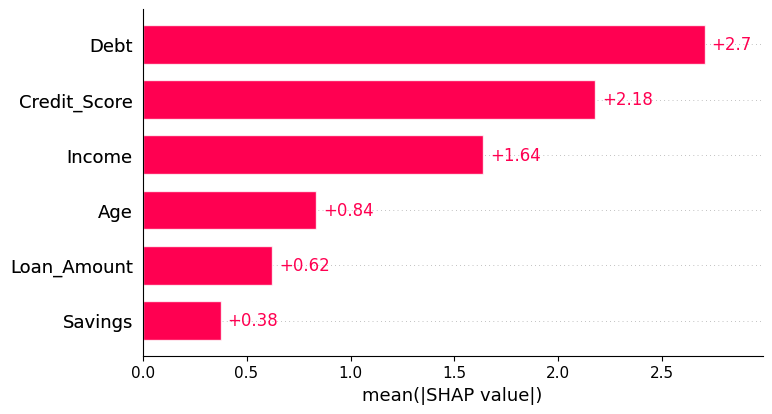

In [25]:
shap.plots.bar(shap_values)




### NOTE

* Bigger bar = more influence on model predictions
* Positive SHAP value → pushes prediction toward default
* Negative SHAP value → pushes prediction away from default

Example:

* High debt may increase risk
* High income may reduce risk



---

# Step 9 — SHAP Summary Plot



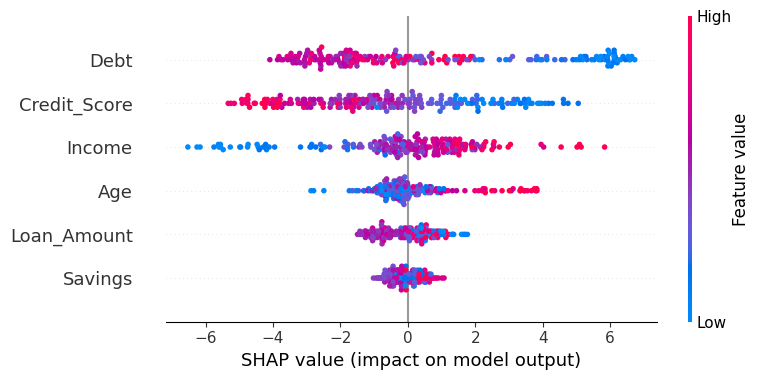

In [26]:
shap.summary_plot(shap_values, X_test)


### Explaination

Each dot = one customer.

Color meaning:

* Red = high feature value
* Blue = low feature value

Horizontal position:

* Left = lowers probability of default
* Right = increases probability of default

Example:

* Red dots on Debt moving right → higher debt increases default risk
* Red dots on Savings moving left → higher savings lowers risk


---

# Step 10 — Explain One Customer



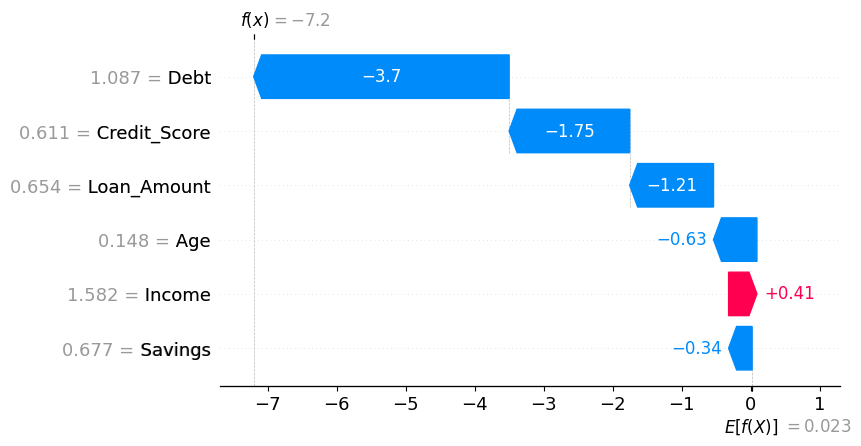

In [27]:
customer_index = 5

shap.plots.waterfall(shap_values[customer_index])


This is a **SHAP Waterfall Plot** for a single customer prediction.

It explains:
> *Why did the model make this prediction?*

---

# Step-by-Step Interpretation

The model starts from the **average prediction**:

$$E[f(X)] = 0.023$$

This is the baseline prediction across all customers.

Then each feature pushes the prediction:
* **Left** $\rightarrow$ decreases prediction
* **Right** $\rightarrow$ increases prediction

Final prediction:

$$f(x) = -7.2 = -3.7 -1.75 -1.21 -0.63 + 0.41 -0.34$$

This is a **very low prediction score**. Depending on the model setup, this likely means:
* Very low probability of default
* Strong prediction toward “non-default”

---

# Feature-by-Feature Interpretation

## 1. Debt = 1.087
* **Largest impact.**
* **Contribution:** $-3.7$
* This strongly pushes the prediction downward.

### Explaination
> “Debt is the most influential factor for this customer.”

In this trained model, this debt value reduced risk prediction significantly. *(Important: SHAP explains the model behavior, not finance logic itself).*

---

## 2. Credit Score = 0.611
* **Contribution:** $-1.75$
* This also lowers prediction strongly.
* **Interpretation:** This credit score value makes the customer appear safer.

---

## 3. Loan Amount = 0.654
* **Contribution:** $-1.21$
* This lowers the prediction further.

---

## 4. Age = 0.148
* **Contribution:** $-0.63$
* Smaller negative effect.

---

## 5. Income = 1.582
* **Contribution:** $+0.41$
* This is the **ONLY** feature increasing prediction.

### Important
> “Higher income increased risk slightly for THIS trained model.”

This is surprising - SHAP explains **what the model learned**, not what humans necessarily expect.

---

## 6. Savings = 0.677
* **Contribution:** $-0.34$
* Small reduction in prediction.

---

# Overall Story

> “The model started near average risk. Then Debt, Credit Score, and Loan Amount strongly pushed the prediction downward. Income slightly pushed risk upward, but not enough to offset the negative contributions. Final prediction became very low.”
